# Credit Card Fraud Detection with Deep Learning and Optuna

## Introduction

This Jupyter Notebook presents a study on credit card fraud detection using deep learning and the hyperparameter optimization tool Optuna. The main goal is to build an accurate and efficient model for identifying fraudulent transactions in a highly imbalanced dataset.

## Methodology

The study follows these steps:

1. **Data preparation:** The credit card transaction dataset available at [this Kaggle link](https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets/input) is loaded. Data preprocessing is performed, including outlier removal and feature scaling.

2. **Data balancing:** SMOTE (Synthetic Minority Over-sampling Technique) is used to address the class imbalance by generating synthetic data for the minority class (fraudulent transactions).

3. **Model building:** A deep neural network (DNN) model is created using the Keras library from TensorFlow. The model architecture consists of dense (fully connected) layers with ReLU activation functions.

4. **Hyperparameter optimization:** Optuna is employed to find the best combination of hyperparameters, such as learning rate, number of units in hidden layers, and batch size. Optuna automates the search process and enables efficient evaluation of different configurations.

5. **Model evaluation:** The model's performance is evaluated using metrics such as precision, recall, F1-score, and AUC (Area Under the Curve) on an independent test dataset.

## Results

The obtained results demonstrate that the model optimized with Optuna achieves high performance in fraud detection. A comparison is presented with a previous study on which this work was based, showing that hyperparameter optimization with Optuna leads to a significant improvement in the results.

## References

- [Kaggle dataset: Credit Card Fraud Detection](https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets/input)
- [Previous study: (https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets/notebook)]

## Conclusions

This study demonstrates the potential of deep learning and hyperparameter optimization for credit card fraud detection. The Optuna tool facilitates the search for optimal model configurations and contributes to improving its performance.

# Detección de Fraude en Tarjetas de Crédito con Aprendizaje Profundo y Optuna

## Introducción

Este Jupyter Notebook presenta un estudio sobre la detección de fraude en tarjetas de crédito utilizando aprendizaje profundo (Deep Learning) y la herramienta de optimización de hiperparámetros Optuna. El objetivo principal es construir un modelo preciso y eficiente para identificar transacciones fraudulentas en un conjunto de datos altamente desbalanceado.

## Metodología

El estudio sigue los siguientes pasos:

1. **Preparación de datos:** Se carga el conjunto de datos de transacciones de tarjetas de crédito disponible en [este enlace de Kaggle](https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets/input). Se realiza un preprocesamiento de datos, incluyendo la eliminación de valores atípicos y el escalado de características.

2. **Balanceo de datos:** Se utiliza la técnica SMOTE (Synthetic Minority Over-sampling Technique) para abordar el desbalanceo de clases, generando datos sintéticos de la clase minoritaria (transacciones fraudulentas).

3. **Construcción del modelo:** Se crea un modelo de red neuronal profunda (DNN) utilizando la librería Keras de TensorFlow. La arquitectura del modelo consiste en capas densas (fully connected) con funciones de activación ReLU.

4. **Optimización de hiperparámetros:** Se utiliza Optuna para encontrar la mejor combinación de hiperparámetros, como la tasa de aprendizaje, el número de unidades en las capas ocultas y el tamaño del lote. Optuna automatiza el proceso de búsqueda y permite evaluar diferentes configuraciones de forma eficiente.

5. **Evaluación del modelo:** Se evalúa el rendimiento del modelo utilizando métricas como precisión, recall, F1-score y AUC (Area Under the Curve) en un conjunto de datos de prueba independiente.

## Resultados

Los resultados obtenidos muestran que el modelo optimizado con Optuna logra un alto rendimiento en la detección de fraude. Se presenta una comparación con un estudio previo en el que se basó este trabajo, demostrando que la optimización de hiperparámetros con Optuna conduce a una mejora significativa en los resultados.

## Referencias

- [Conjunto de datos de Kaggle: Credit Card Fraud Detection](https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets/input)
- [Estudio previo: (https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets/notebook)]

## Conclusiones

Este estudio demuestra el potencial del aprendizaje profundo y la optimización de hiperparámetros para la detección de fraude en tarjetas de crédito. La herramienta Optuna facilita la búsqueda de configuraciones óptimas del modelo y contribuye a mejorar su rendimiento.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler

In [48]:
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
import os
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [3]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix

In [4]:
from tensorflow.keras.metrics import Precision, Recall

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

In [6]:
random_seed = 1

In [7]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
scaler = RobustScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df["Time"] = scaler.fit_transform(df["Time"].values.reshape(-1,1))
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,0.118914,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,0.927124,0.001727
std,0.557903,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,3.495006,0.041527
min,-0.994983,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,-0.307413,0.000000
25%,-0.358210,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,-0.229162,0.000000
50%,0.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,0.000000,0.000000
75%,0.641790,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,0.770838,0.000000
max,1.035022,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,358.683155,1.000000


<ipython-input-10-de68383fccd1>:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort = True)


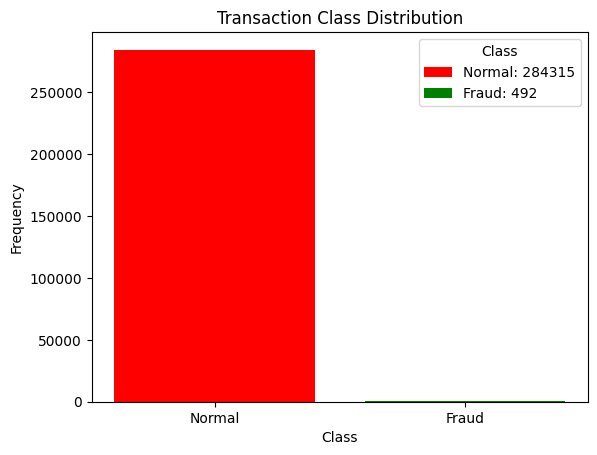

In [10]:
fig, ax = plt.subplots()

classes = df['Class'].value_counts()
count_classes = pd.value_counts(df['Class'], sort = True)
ax.bar(count_classes.index, count_classes.values, color=['red', 'green'], label=[f'Normal: {classes[0]}', f'Fraud: {classes[1]}'])
plt.title("Transaction Class Distribution")
plt.xticks(range(2), ['Normal', 'Fraud'])
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.legend(title='Class', loc='upper right')
plt.show()

In [11]:
df_non_fraud = df[df['Class'] == 0]
df_fraud = df[df['Class'] == 1]
non_fraud_percent = (len(df_non_fraud) / len(df)) * 100
fraud_percent = (len(df_fraud) / len(df)) * 100
print('Non-fraud transactions: ', non_fraud_percent)
print('Fraud transactions: ', fraud_percent)

Non-fraud transactions:  99.82725143693798
Fraud transactions:  0.1727485630620034


In [12]:
df = df.sample(frac=1, random_state=random_seed)
X = df.drop('Class', axis=1)
y = df['Class']
# split 80 20
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X, y, test_size=0.2, random_state=random_seed)
# distribution
train_unique_label, train_counts_label = np.unique(y_train_original, return_counts=True)
test_unique_label, test_counts_label = np.unique(y_test_original, return_counts=True)
print('Distribution')
print(train_counts_label/ len(y_train_original))
print(test_counts_label/ len(y_test_original))

Distribution
[0.99824881 0.00175119]
[0.99836733 0.00163267]


In [13]:
df_non_fraud_undersampled = df_non_fraud.sample(len(df_fraud), random_state=random_seed)
df_non_fraud_undersampled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
106066,-0.174861,0.136174,-1.647766,0.850033,1.576178,-1.569057,-0.106752,0.026632,-0.091738,0.517553,...,0.584649,0.582371,-0.548530,0.456719,0.202315,-0.314320,-0.018220,0.138062,7.238175,0
102005,-0.195926,-0.911610,0.680815,1.344329,-0.068517,0.596394,-1.268838,0.769226,-0.134888,-0.247848,...,0.139301,0.252879,-0.228605,0.360421,0.043382,-0.588531,-0.026174,0.159864,-0.211137,0
278450,0.981438,-0.917299,0.860942,1.201170,-0.962314,-0.372495,-0.114847,0.001741,0.699885,-0.040284,...,-0.138630,-0.493530,0.001530,-0.370406,-0.392434,0.304997,0.177416,0.115137,-0.028086,0
120218,-0.105041,1.252596,0.021359,0.044063,0.325909,0.011174,-0.053598,-0.097035,0.013237,0.263268,...,-0.096153,-0.266459,-0.071237,-0.749998,0.389529,0.494047,-0.029793,0.002433,-0.058688,0
258527,0.869395,-1.109483,1.061341,1.484072,0.923891,-0.137718,0.816640,0.014252,0.938303,-0.125829,...,-0.479951,-1.369632,-0.020618,0.578319,0.329709,-0.825568,0.209439,0.068794,0.034654,0


In [14]:
new_df_undersampled_balanced = pd.concat([df_non_fraud_undersampled, df_fraud])
new_df_undersampled_balanced

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
106066,-0.174861,0.136174,-1.647766,0.850033,1.576178,-1.569057,-0.106752,0.026632,-0.091738,0.517553,...,0.584649,0.582371,-0.548530,0.456719,0.202315,-0.314320,-0.018220,0.138062,7.238175,0
102005,-0.195926,-0.911610,0.680815,1.344329,-0.068517,0.596394,-1.268838,0.769226,-0.134888,-0.247848,...,0.139301,0.252879,-0.228605,0.360421,0.043382,-0.588531,-0.026174,0.159864,-0.211137,0
278450,0.981438,-0.917299,0.860942,1.201170,-0.962314,-0.372495,-0.114847,0.001741,0.699885,-0.040284,...,-0.138630,-0.493530,0.001530,-0.370406,-0.392434,0.304997,0.177416,0.115137,-0.028086,0
120218,-0.105041,1.252596,0.021359,0.044063,0.325909,0.011174,-0.053598,-0.097035,0.013237,0.263268,...,-0.096153,-0.266459,-0.071237,-0.749998,0.389529,0.494047,-0.029793,0.002433,-0.058688,0
258527,0.869395,-1.109483,1.061341,1.484072,0.923891,-0.137718,0.816640,0.014252,0.938303,-0.125829,...,-0.479951,-1.369632,-0.020618,0.578319,0.329709,-0.825568,0.209439,0.068794,0.034654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,0.992140,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,5.142178,1
280143,0.994549,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,-0.296793,1
280149,0.994596,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,0.780968,1
281144,1.001821,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,3.116048,1


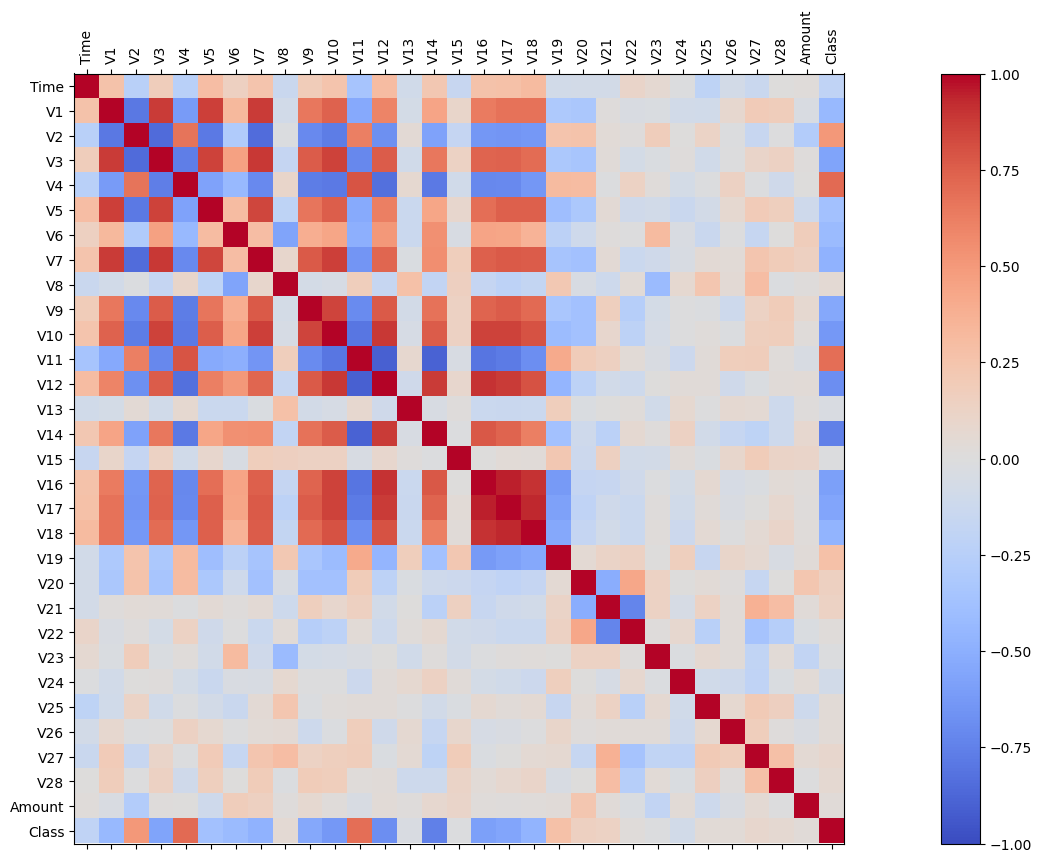

In [15]:
fig, ax = plt.subplots(figsize=(25,10))
sub_sample_corr = new_df_undersampled_balanced.corr()
cax = ax.matshow(sub_sample_corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
plt.xticks(range(len(sub_sample_corr.columns)), sub_sample_corr.columns, rotation='vertical')
plt.yticks(range(len(sub_sample_corr.columns)), sub_sample_corr.columns)
plt.show()

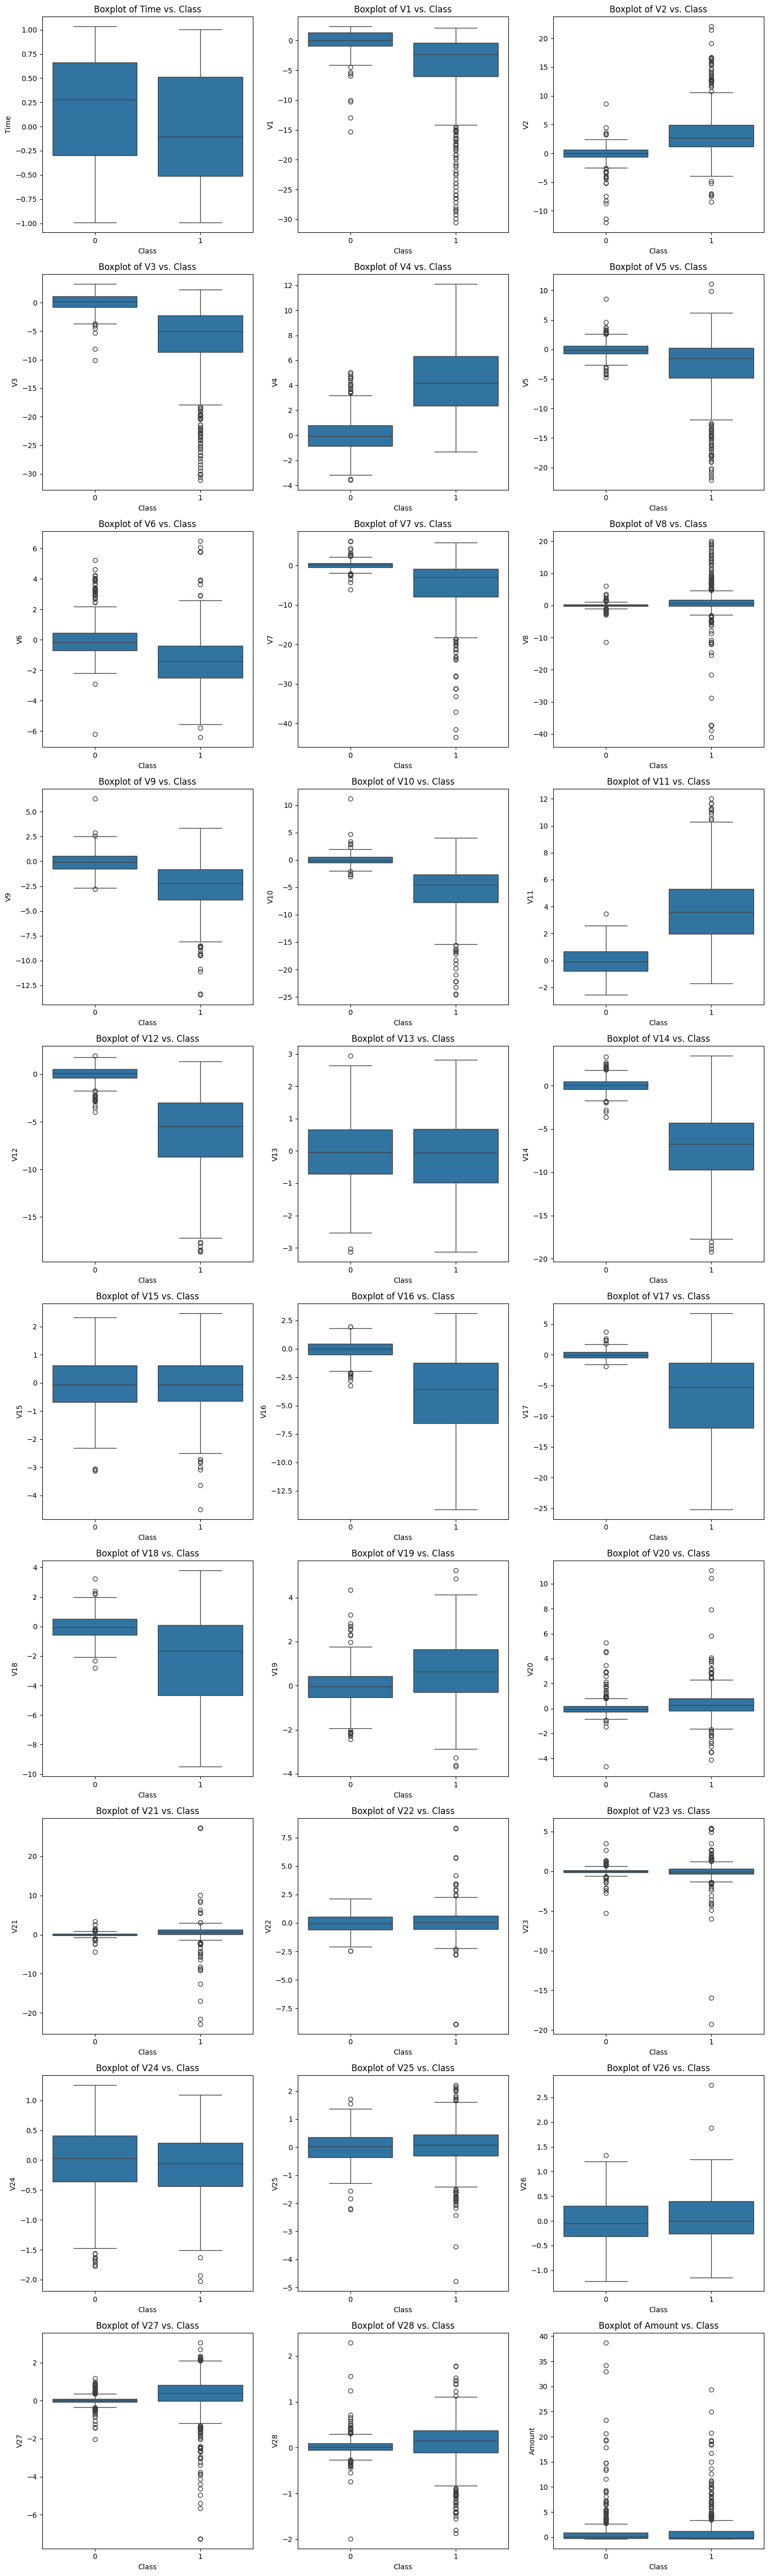

In [16]:
# Lista de features
features = new_df_undersampled_balanced.drop('Class', axis=1).columns

num_features = len(features)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
if num_rows == 1:
    axes = [axes]
else:
  axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x="Class", y=feature, data=new_df_undersampled_balanced, ax=axes[i])
    axes[i].set_title(f"Boxplot of {feature} vs. Class")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
#  K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Cross validation con SMOTE
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

In [20]:
# Métricas
accuracy_lst = []
precision_lst = []
recall_lst = []
f1_lst = []
auc_lst = []
models = []
history_list = []

n_inputs = X_train.shape[1]

def Clasificador_NN(input_dim):
    model = Sequential([
        Dense(n_inputs, input_shape=(n_inputs, ), activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=random_seed)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Definimos el clasificador
model = Clasificador_NN(input_dim=X_train_resampled.shape[1])
early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train_resampled, y_train_resampled,
    validation_split=0.2,
    epochs=50, batch_size=400, verbose=1,
    callbacks=[early_stopping], shuffle=True
)

# Historial
history_list.append(history)

# Predicciones
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Métricas
accuracy_lst.append(model.evaluate(X_test, y_test, verbose=0)[1])
precision_lst.append(precision_score(y_test, y_pred))
recall_lst.append(recall_score(y_test, y_pred))
f1_lst.append(f1_score(y_test, y_pred))
auc_lst.append(roc_auc_score(y_test, y_pred))
models.append(model)

print('---' * 45)
print('')
print("Accuracy: {:.4f}".format(np.mean(accuracy_lst)))
print("Precision: {:.4f}".format(np.mean(precision_lst)))
print("Recall: {:.4f}".format(np.mean(recall_lst)))
print("F1 Score: {:.4f}".format(np.mean(f1_lst)))
print("AUC: {:.4f}".format(np.mean(auc_lst)))
print('---' * 45)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
910/910 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9313 - loss: 0.1851 - val_accuracy: 0.9879 - val_loss: 0.0419
Epoch 2/50
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9932 - loss: 0.0238 - val_accuracy: 0.9992 - val_loss: 0.0111
Epoch 3/50
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9979 - loss: 0.0097 - val_accuracy: 0.9996 - val_loss: 0.0063
Epoch 4/50
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9989 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 5/50
910/910 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9991 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 6/50
910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9993 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 7/50
910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 8/50
910/910 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 1.

In [21]:
best_model_index = np.argmax(precision_lst)
best_model = models[best_model_index]
print("Best precision_lst: {:.4f}".format(precision_lst[best_model_index]))

Best precision_lst: 0.7723


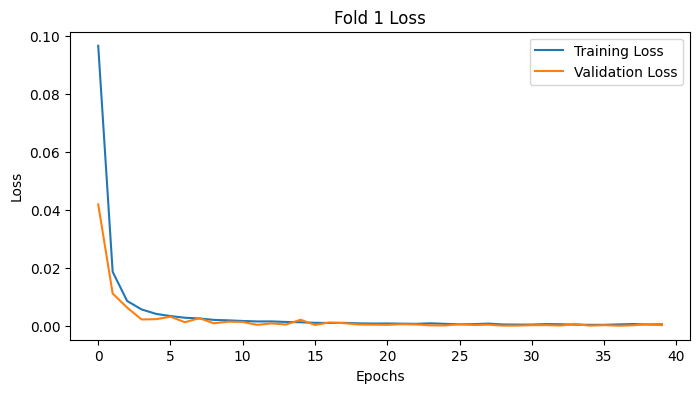

In [22]:
for i, history in enumerate(history_list):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Fold {i + 1} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [23]:
y_pred_probs = model.predict(X_test)
y_pred_SMOTE = np.argmax(y_pred_probs, axis=1)
y_pred_SMOTE

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


array([0, 0, 0, ..., 0, 0, 0])

Text(0, 0.5, 'Precision')

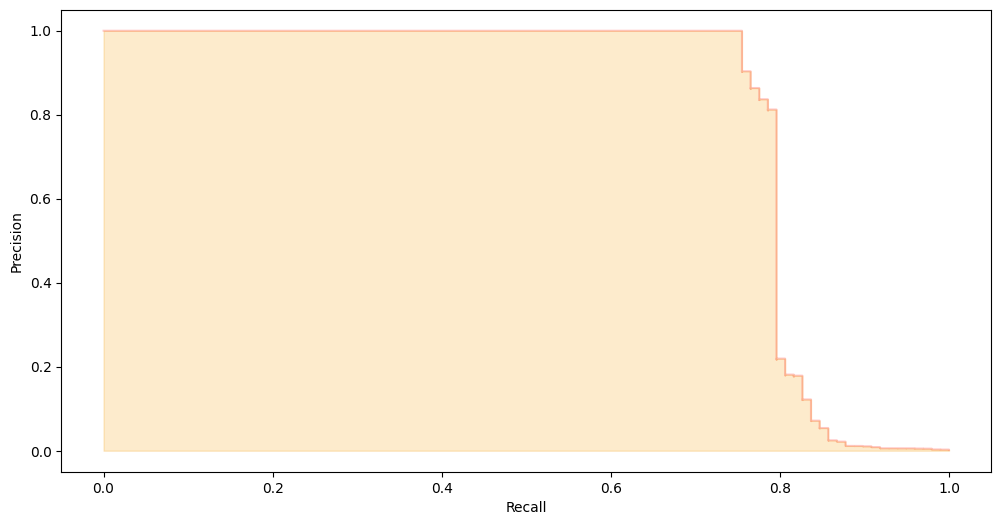

In [28]:
fig = plt.figure(figsize=(12,6))

precision, recall, _ = precision_recall_curve(y_test, y_pred_probs[:, 1])

plt.step(recall,precision,color='r',alpha=0.2,where='post')
plt.fill_between(recall,precision,step='post',alpha=0.2,color='#F59B00')
plt.xlabel('Recall')
plt.ylabel('Precision')


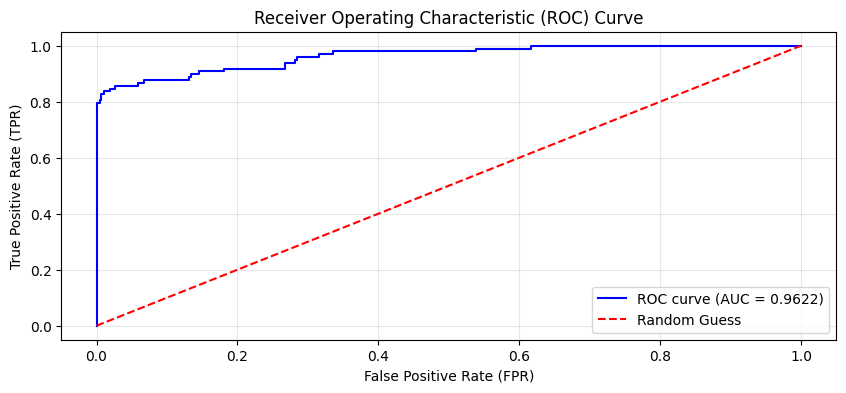

In [31]:
y_pred_probs_positive = y_pred_probs[:, 1]
fpr, tpr, thresholds = roc_curve(y_test,y_pred_probs_positive)

# Calculamos el AUC
roc_auc=roc_auc_score(y_test, y_pred_probs_positive)

plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='r', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [25]:
def plot_confusion_matrix(cm, classes, normalize=False,title='Confusion matrix',cmap=plt.cm.Blues):
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[56840    23]
 [   20    78]]


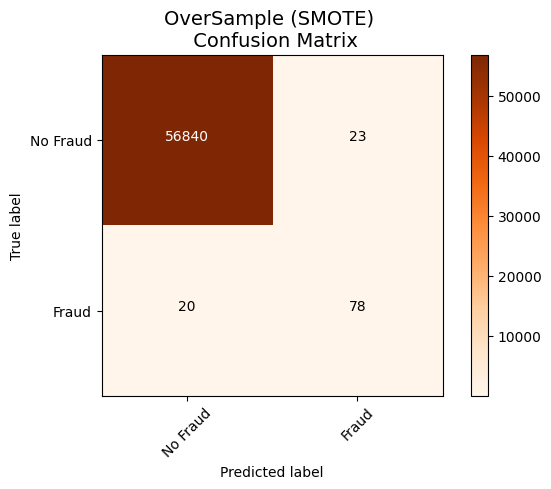

In [27]:
conf_NN = confusion_matrix(y_test, y_pred_SMOTE)
labels = ['No Fraud', 'Fraud']
plot_confusion_matrix(conf_NN, labels, title="OverSample (SMOTE) \n Confusion Matrix", cmap=plt.cm.Oranges)

In [32]:
precision_score(y_test, y_pred)

0.7722772277227723

In [34]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 5.8 MB/s eta 0:00:00


In [51]:
import optuna

In [52]:
trial_histories = {}

In [57]:
def objective(trial):
    # Definimos el espacio de búsqueda
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
    n_units_layer1 = trial.suggest_int('n_units_layer1', 16, 128, step=16)
    n_units_layer2 = trial.suggest_int('n_units_layer2', 8, 64, step=8)
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 400])
    epochs = trial.suggest_int('epochs', 10, 50, step=5)

    model = Sequential([
        Dense(n_units_layer1, input_shape=(X_train_resampled.shape[1],), activation='relu'),
        Dense(n_units_layer2, activation='relu'),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model_path = f"trial_model_{trial.number}.keras"
    checkpoint = ModelCheckpoint(model_path, save_best_only=True, save_weights_only=False, monitor='loss', mode='min')

    history = model.fit(
        X_train_resampled, y_train_resampled,
        validation_split=0.2,
        epochs=epochs, batch_size=batch_size, verbose=1,
        callbacks=[checkpoint], shuffle=True
    )

    model.load_weights(model_path)

    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    f1 = f1_score(y_test, y_pred)

    trial.set_user_attr("loss", history.history['loss'])
    trial.set_user_attr("val_loss", history.history['val_loss'])
    trial_histories[trial.number] = history.history

    return f1

In [58]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

best_trial_number = study.best_trial.number
best_loss_history = trial_histories[best_trial_number]['loss']
best_val_loss_history = trial_histories[best_trial_number]['val_loss']

print(f"Historial de pérdida del mejor modelo (Trial {best_trial_number}):")
print("Loss:", best_loss_history)
print("Validation Loss:", best_val_loss_history)

[I 2025-01-13 00:27:52,258] A new study created in memory with name: no-name-659c8df7-d951-48f2-873a-885c03d23381
<ipython-input-57-687ad8f76e8f>:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7767 - loss: 0.4495 - val_accuracy: 0.9363 - val_loss: 0.1126
Epoch 2/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9745 - loss: 0.0655 - val_accuracy: 0.9774 - val_loss: 0.0557
Epoch 3/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9900 - loss: 0.0334 - val_accuracy: 0.9949 - val_loss: 0.0223
Epoch 4/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9958 - loss: 0.0184 - val_accuracy: 0.9994 - val_loss: 0.0134
Epoch 5/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9976 - loss: 0.0120 - val_accuracy: 0.9997 - val_loss: 0.0081
Epoch 6/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9984 - loss: 0.0085 - val_accuracy: 0.9997 - val_loss: 0.0078
Epoch 7/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9988 - loss: 0.0061 - val_accuracy: 0.9998 - val_loss: 0.0051
Epoch 8/25
910/910 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9990 - loss: 0.0046 - val_accuracy: 0.

[I 2025-01-13 00:29:29,091] Trial 0 finished with value: 0.7761194029850746 and parameters: {'learning_rate': 0.00024575221012695074, 'n_units_layer1': 96, 'n_units_layer2': 16, 'batch_size': 400, 'epochs': 25}. Best is trial 0 with value: 0.7761194029850746.
<ipython-input-57-687ad8f76e8f>:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9675 - loss: 0.0993 - val_accuracy: 0.9997 - val_loss: 0.0082
Epoch 2/10
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9987 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 3/10
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9993 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 4/10
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9995 - loss: 0.0026 - val_accuracy: 0.9997 - val_loss: 0.0021
Epoch 5/10
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9996 - loss: 0.0021 - val_accuracy: 0.9995 - val_loss: 0.0030
Epoch 6/10
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 0.9999 - val_loss: 0.0025
Epoch 7/10
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 7.1904e-04
Epoch 8/10
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9996 - loss: 0.

[I 2025-01-13 00:31:19,027] Trial 1 finished with value: 0.7536231884057971 and parameters: {'learning_rate': 0.0006535812657099587, 'n_units_layer1': 80, 'n_units_layer2': 56, 'batch_size': 128, 'epochs': 10}. Best is trial 0 with value: 0.7761194029850746.
<ipython-input-57-687ad8f76e8f>:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/40
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9662 - loss: 0.1035 - val_accuracy: 0.9999 - val_loss: 0.0053
Epoch 2/40
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9985 - loss: 0.0069 - val_accuracy: 0.9998 - val_loss: 0.0027
Epoch 3/40
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9991 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 6.7833e-04
Epoch 4/40
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9990 - val_loss: 0.0045
Epoch 5/40
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 8.4709e-04
Epoch 6/40
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 1.9715e-04
Epoch 7/40
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 5.4792e-04
Epoch 8/40
2844/2844 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9997

[I 2025-01-13 01:32:40,134] Trial 18 finished with value: 0.7783251231527094 and parameters: {'learning_rate': 0.0007763684081315836, 'n_units_layer1': 64, 'n_units_layer2': 56, 'batch_size': 128, 'epochs': 40}. Best is trial 7 with value: 0.8253968253968254.
<ipython-input-57-687ad8f76e8f>:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
910/910 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9695 - loss: 0.0820 - val_accuracy: 0.9999 - val_loss: 0.0060
Epoch 2/30
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9987 - loss: 0.0068 - val_accuracy: 0.9997 - val_loss: 0.0026
Epoch 3/30
910/910 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9991 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 4/30
910/910 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 5/30
910/910 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9996 - loss: 0.0020 - val_accuracy: 0.9997 - val_loss: 0.0011
Epoch 6/30
910/910 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 2.4221e-04
Epoch 7/30
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9997 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 2.9079e-04
Epoch 8/30
910/910 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9995 - loss: 0.0017 - val_accu

[I 2025-01-13 01:34:59,396] Trial 19 finished with value: 0.751219512195122 and parameters: {'learning_rate': 0.0012914097227737442, 'n_units_layer1': 128, 'n_units_layer2': 24, 'batch_size': 400, 'epochs': 30}. Best is trial 7 with value: 0.8253968253968254.


Historial de pérdida del mejor modelo (Trial 7):
Loss: [0.06571894884109497, 0.012543745338916779, 0.006047906819730997, 0.003920099698007107, 0.002978052245453, 0.0024794270284473896, 0.001965748844668269, 0.0016645209398120642, 0.0015122457407414913, 0.0012673160526901484, 0.0011059328680858016, 0.001034434768371284, 0.0011568590998649597, 0.0007791992975398898, 0.0006942051695659757, 0.000712105305865407, 0.0006846399046480656, 0.0005919240065850317, 0.0007215531659312546, 0.0005815285257995129, 0.0004344043554738164, 0.0006594503647647798, 0.0004047453112434596, 0.00039765439578332007, 0.0005107982433401048, 0.0005124984309077263, 0.0005125197349116206, 0.00033391854958608747, 0.00035010947613045573, 0.0006202940130606294, 0.00023522831907030195, 0.0005343943485058844, 0.00033370463643223047, 0.00025387556524947286, 0.0006106815999373794, 0.0002782064548227936, 0.00023900915402919054, 0.00032562151318416, 0.00023358700855169445, 0.00023790457635186613]
Validation Loss: [0.024301512

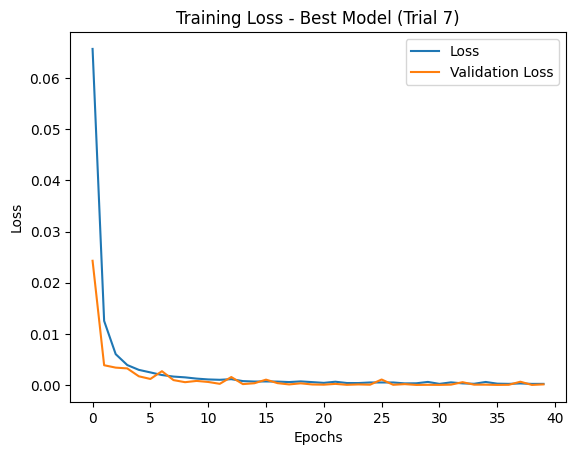

In [59]:
plt.plot(best_loss_history, label='Loss')
plt.plot(best_val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f"Training Loss - Best Model (Trial {best_trial_number})")
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


---------------------------------------------------------------------------------------------------------------------------------------

Accuracy: 0.9994
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Precision: 0.8571
Recall: 0.7959
F1 Score: 0.8254
AUC: 0.9545
---------------------------------------------------------------------------------------------------------------------------------------


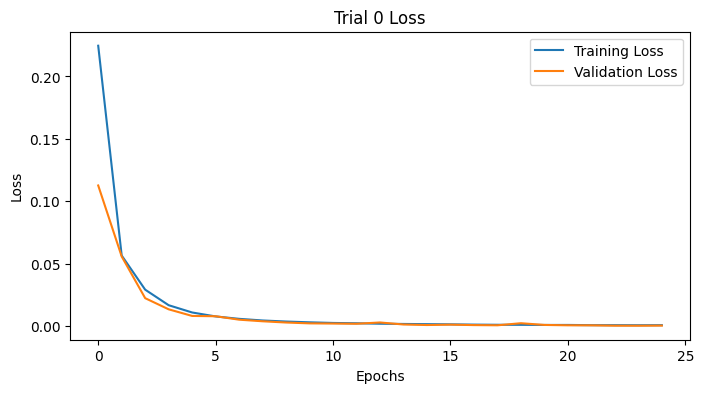

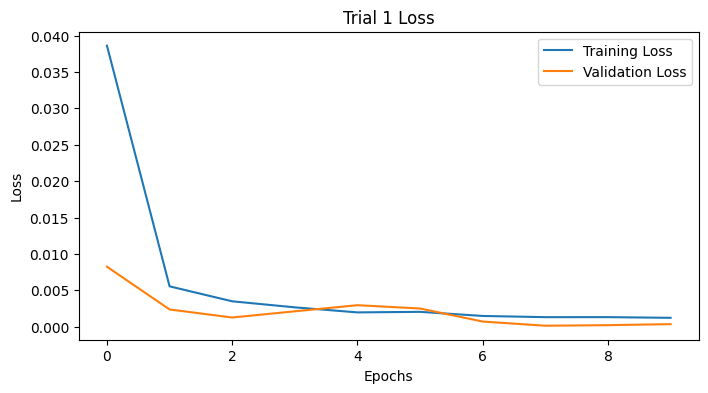

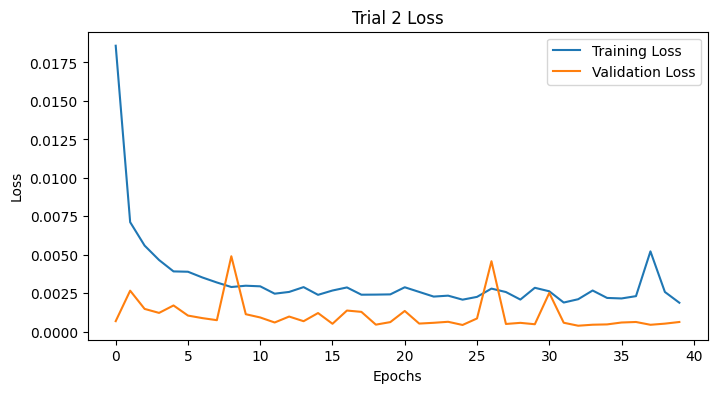

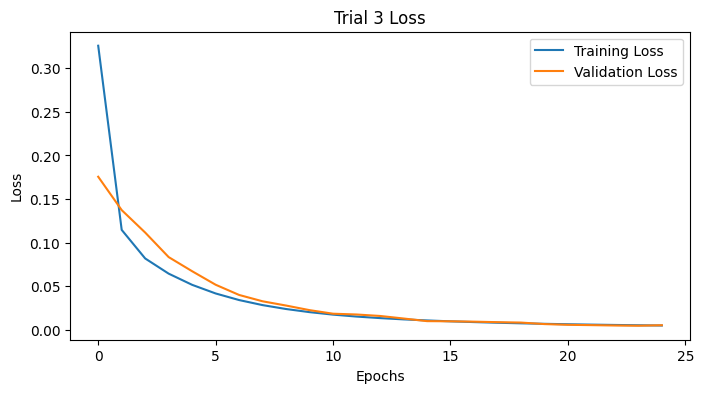

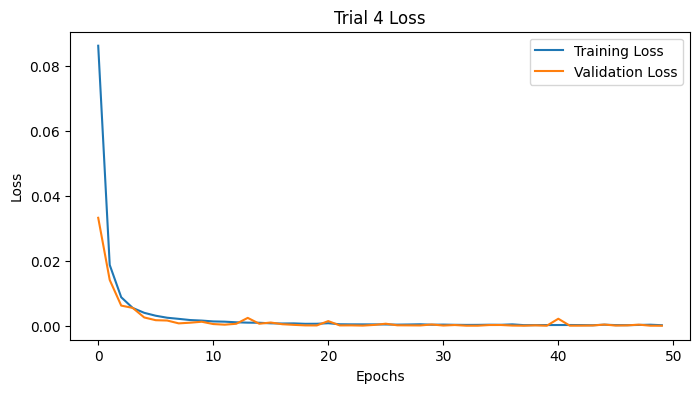

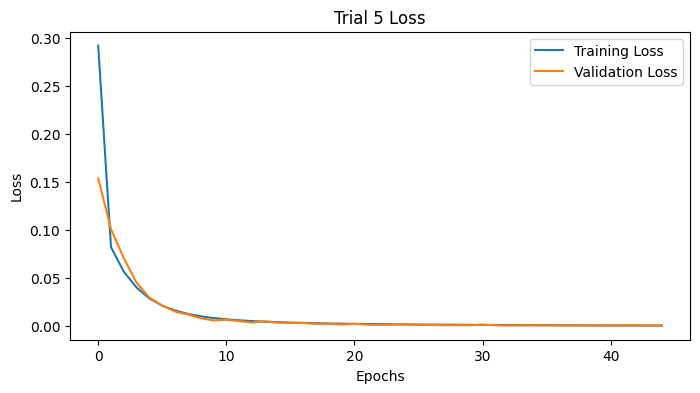

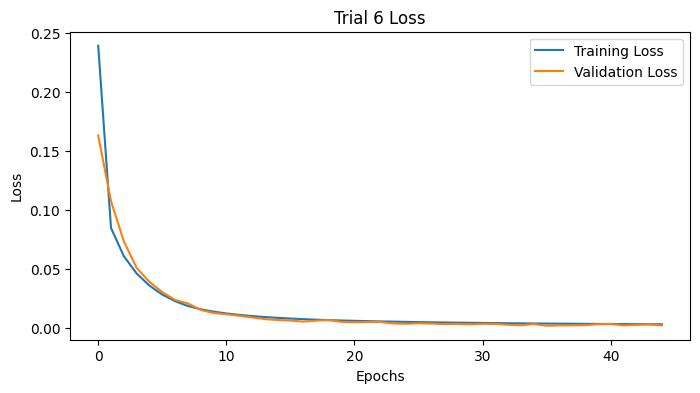

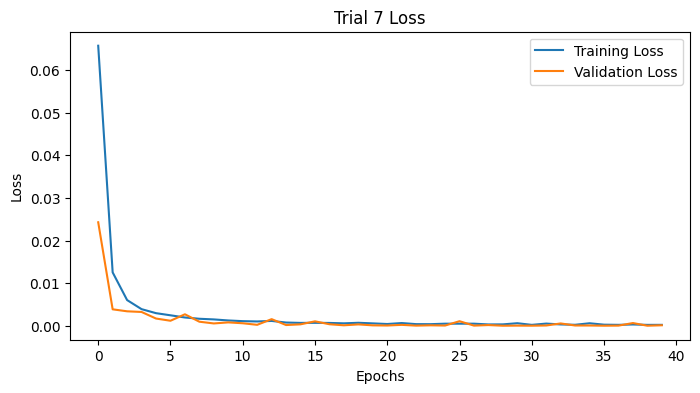

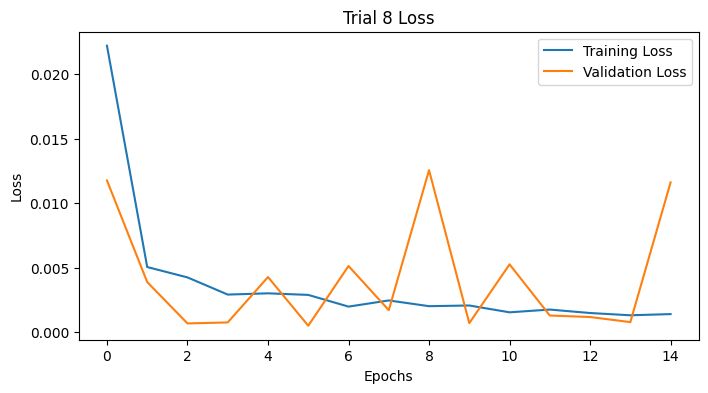

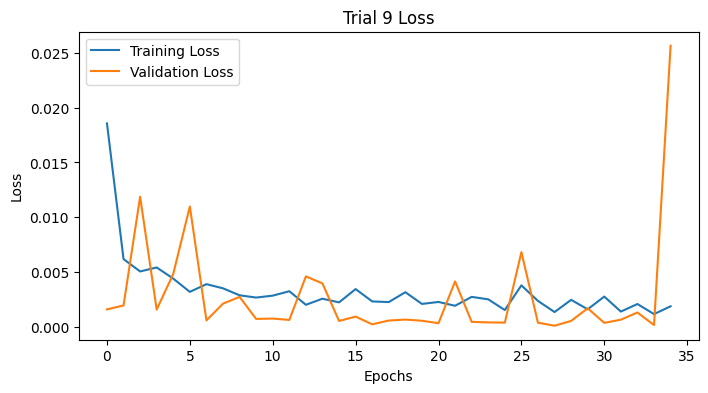

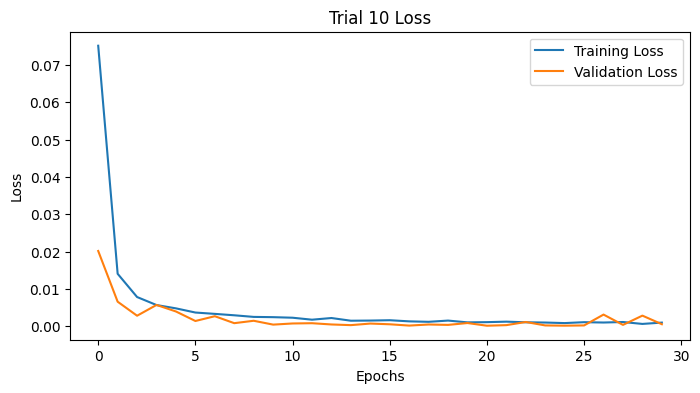

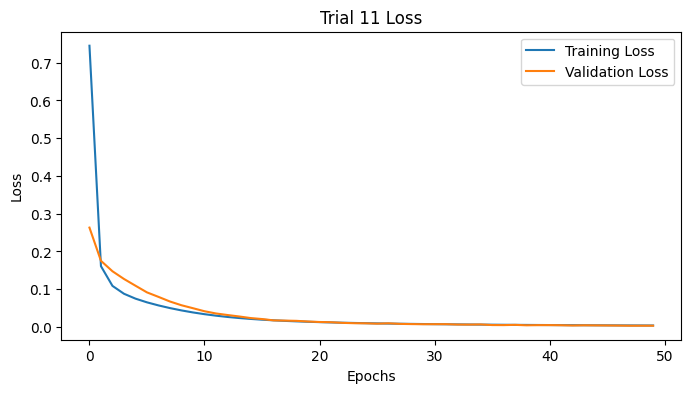

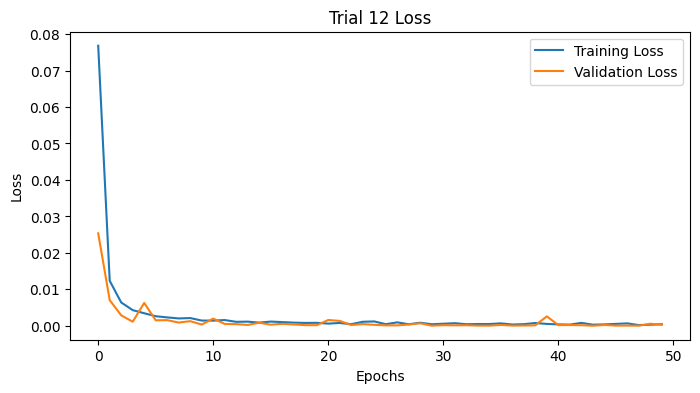

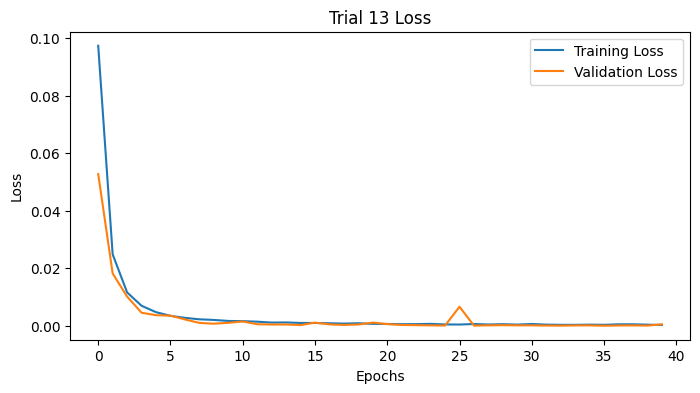

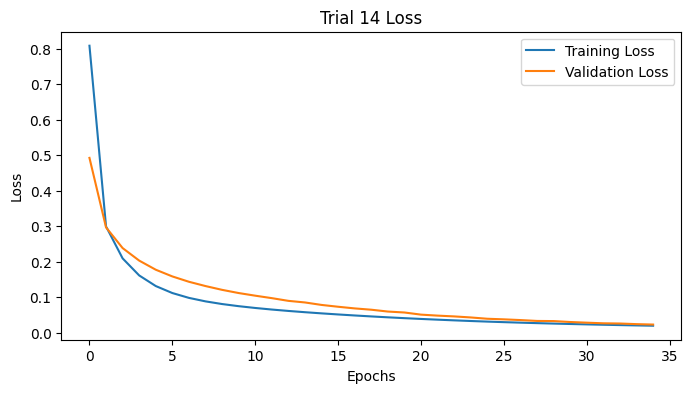

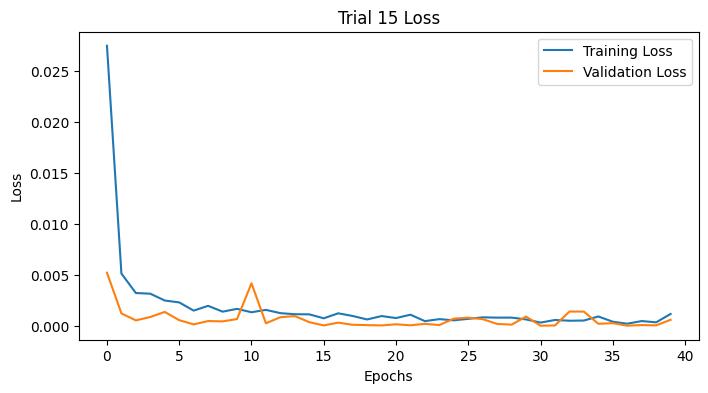

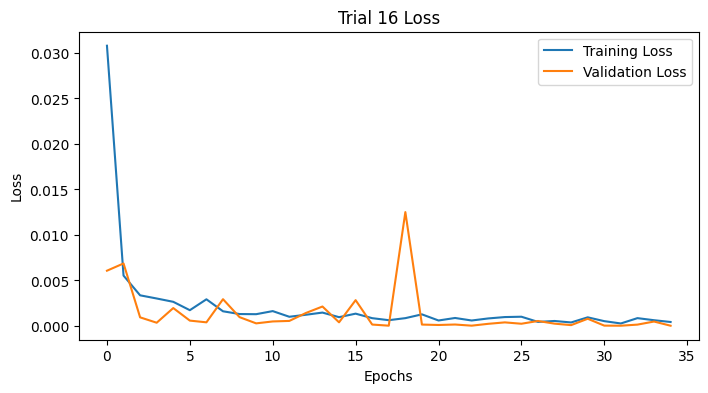

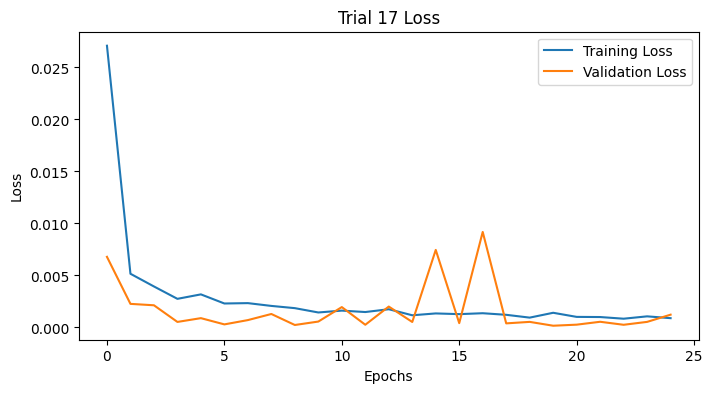

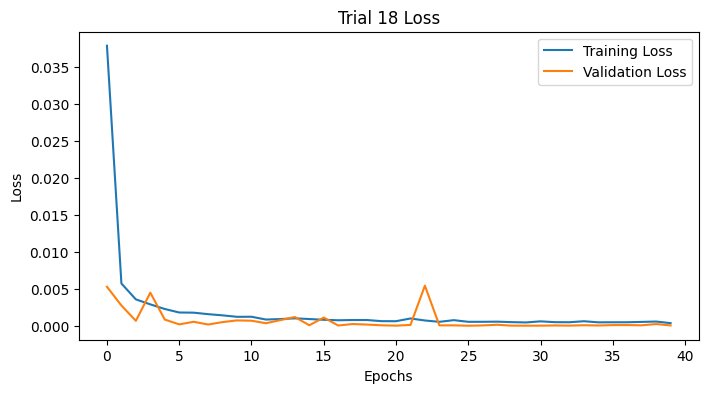

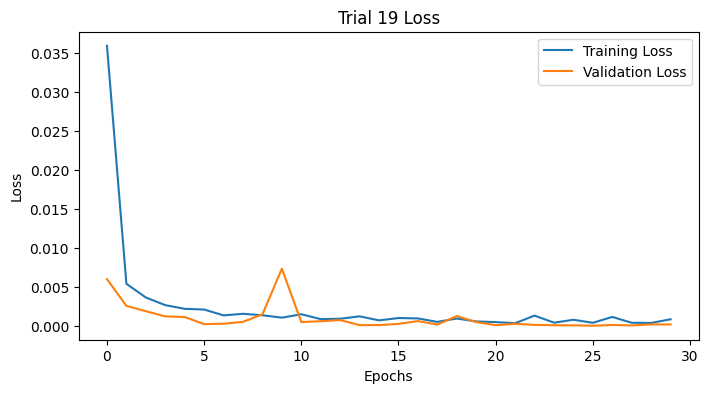

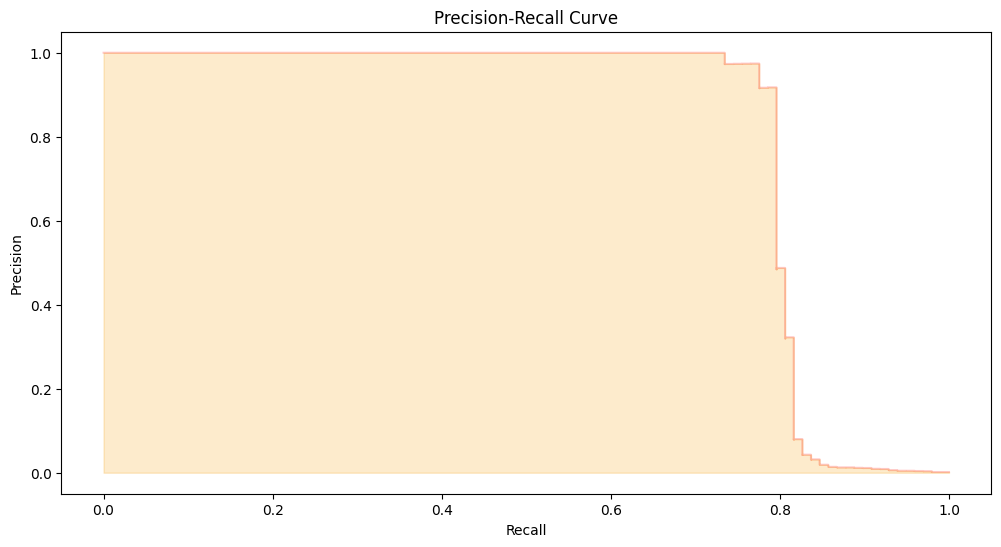

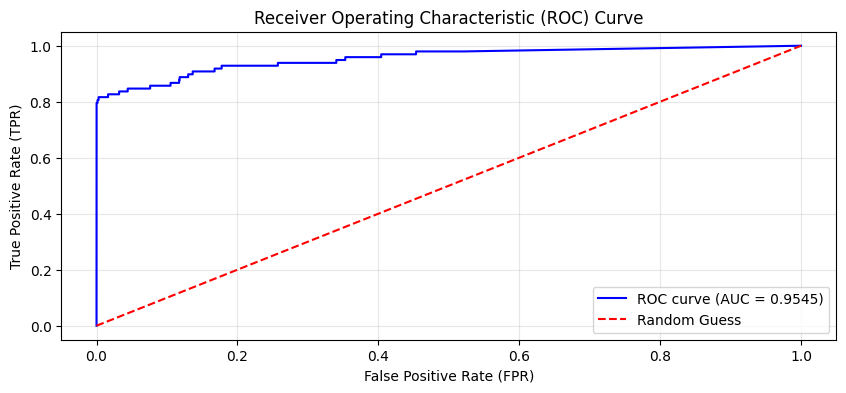

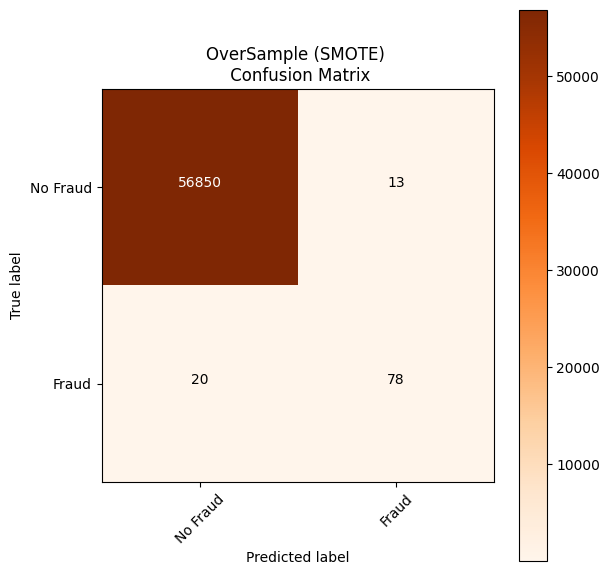

In [61]:
best_model = Sequential([
    Dense(study.best_trial.params['n_units_layer1'], input_shape=(X_train_resampled.shape[1],), activation='relu'),
    Dense(study.best_trial.params['n_units_layer2'], activation='relu'),
    Dense(2, activation='softmax')
])
# Carga del mejor modelo
best_model.load_weights(f"trial_model_{7}.keras")
best_model.compile(optimizer=Adam(learning_rate=study.best_trial.params['learning_rate']),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print('---' * 45)
print('')
accuracy = best_model.evaluate(X_test, y_test, verbose=0)[1]
print("Accuracy: {:.4f}".format(accuracy))

y_pred_probs = best_model.predict(X_test)
y_pred_SMOTE = np.argmax(y_pred_probs, axis=1)

precision = precision_score(y_test, y_pred_SMOTE)
recall = recall_score(y_test, y_pred_SMOTE)
f1 = f1_score(y_test, y_pred_SMOTE)
auc = roc_auc_score(y_test, y_pred_probs[:, 1])

print("Precision: {:.4f}".format(precision))
print("Recall: {:.4f}".format(recall))
print("F1 Score: {:.4f}".format(f1))
print("AUC: {:.4f}".format(auc))
print('---' * 45)

for i, (trial_num, history) in enumerate(trial_histories.items()):
    plt.figure(figsize=(8, 4))
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'Trial {trial_num} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

fig = plt.figure(figsize=(12, 6))
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs[:, 1])
plt.step(recall, precision, color='r', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='#F59B00')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs[:, 1])
roc_auc = roc_auc_score(y_test, y_pred_probs[:, 1])
plt.figure(figsize=(10, 4))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='r', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

conf_NN = confusion_matrix(y_test, y_pred_SMOTE)
labels = ['No Fraud', 'Fraud']
def plot_confusion_matrix(cm, labels, title, cmap):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

plot_confusion_matrix(conf_NN, labels, title="OverSample (SMOTE) \n Confusion Matrix", cmap=plt.cm.Oranges)